# Lorenz-96 Localized EnKF and Learned Regularization

See Chapter 6, Section 6.3.5: Ensemble Kalman Filter; Chapter 9, Section 9.2.3: Learning Localization And Inflation In EnKF.

The Lorenz-96 benchmark has state $v\in\mathbb{R}^{d}$ and cyclic dynamics
$$
\frac{dv_k}{dt}=(v_{k+1}-v_{k-2})v_{k-1}-v_k+F,\qquad k=1,\ldots,d,
$$
with cyclic boundary conditions. The stochastic discrete-time model is
$$
v_{j+1}=\Psi(v_j)+\xi_j,\qquad \xi_j\sim\mathcal{N}(0,\Sigma),
$$
and the fully observed data model is
$$
y_j=v_j+\eta_j,\qquad \eta_j\sim\mathcal{N}(0,\Gamma).
$$

For the perturbed-observation EnKF, each forecast member is
$$
\hat v_j^{(n)}=\Psi(v_{j-1}^{(n)})+\xi_j^{(n)},\qquad
\xi_j^{(n)}\sim\mathcal{N}(0,\Sigma).
$$
The predictive means are
$$
\bar v_j=\frac{1}{N}\sum_{n=1}^{N}\hat v_j^{(n)},\qquad
\bar h_j=\frac{1}{N}\sum_{n=1}^{N}h(\hat v_j^{(n)}).
$$
The empirical covariance matrices are
$$
\hat C^{vh}_j=
\frac{1}{N-1}\sum_{n=1}^{N}
(\hat v_j^{(n)}-\bar v_j)\otimes
(h(\hat v_j^{(n)})-\bar h_j),
$$
$$
\hat C^{hh}_j=
\frac{1}{N-1}\sum_{n=1}^{N}
(h(\hat v_j^{(n)})-\bar h_j)\otimes
(h(\hat v_j^{(n)})-\bar h_j).
$$
The stochastic analysis update is
$$
v_j^{(n)}
=\hat v_j^{(n)}
+\hat C^{vh}_j(\hat C^{hh}_j+\Gamma)^{-1}
\left(y^\dagger_j-h(\hat v_j^{(n)})-\eta_j^{(n)}\right).
$$

In high dimension, localization and inflation are essential. Localization modifies the state-observation covariance by
$$
\hat C^{vh}_{j,\operatorname{loc}}=L\circ\hat C^{vh}_j,
$$
where
$$
L_{ki}=C_0(d(k,i),r)=
\begin{cases}
1-\frac{5}{3}x^2+\frac{5}{8}x^3+\frac{1}{2}x^4-\frac{1}{4}x^5, & 0\leq d<r,\\
4-5x+\frac{5}{3}x^2+\frac{5}{8}x^3-\frac{1}{2}x^4+\frac{1}{12}x^5-\frac{2}{3x}, & r\leq d<2r,\\
0, & d\geq 2r,
\end{cases}
$$
with $x=d/r$. Post-analysis multiplicative inflation is
$$
v_j^{(n)}\leftarrow
\bar v_j^{\rm ana}+\alpha(v_j^{(n)}-\bar v_j^{\rm ana}),
$$
where
$$
\bar v_j^{\rm ana}=\frac{1}{N}\sum_{n=1}^{N}v_j^{(n)}.
$$
We learn $\theta_{\rm reg}=\{\alpha,r\}$ by minimizing a supervised filtering loss over training trajectories,
$$
\mathcal{L}(\theta_{\rm reg})
=\frac{1}{J}\sum_{j=1}^{J}\|\bar v_j^{\rm ana}(\theta_{\rm reg})-v_j^\dagger\|^2,
$$
and evaluate with
$$
\operatorname{RMSE}=
\sqrt{\frac{1}{J_{\rm test}\,d}
\sum_{j=1}^{J_{\rm test}}\sum_{k=1}^{d}
(v_{j,k}^{\rm est}-v_{j,k}^\dagger)^2}.
$$


**Parameter exploration.**

- Reduce `ensemble_size` to make spurious correlations and filter divergence more visible; localization should then matter more.
- Compare `baseline_radius`: small radii can ignore useful observations, while very large radii reintroduce noisy long-range correlations.
- Increase `sigma_y` to make observations less trustworthy; the best radius and inflation can shift.
- Toggle `force_retrain` only when you want to ignore an existing checkpoint and rerun the regularization search.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `ensemble_size` | `sigma_y` | `baseline_radius` | Purpose |
|---:|---:|---:|---|
| 10 | 1.0 | 4.0 | Stress case where poor regularization may diverge. |
| 30 | 1.0 | 4.0 | Balanced high-dimensional EnKF default. |
| 30 | 1.5 | 2.0 | Noisier observations with a deliberately local baseline. |
| 50 | 1.0 | 8.0 | Larger ensemble with a broader localization radius. |


Loaded checkpoint: checkpoints/lorenz96_localized_enkf_regularization/grid_learning/f6f7d70cb8ec.pkl
Learned regularization: alpha=1.0, radius=8.0
Baseline RMSE: 0.484
Learned RMSE:  0.341


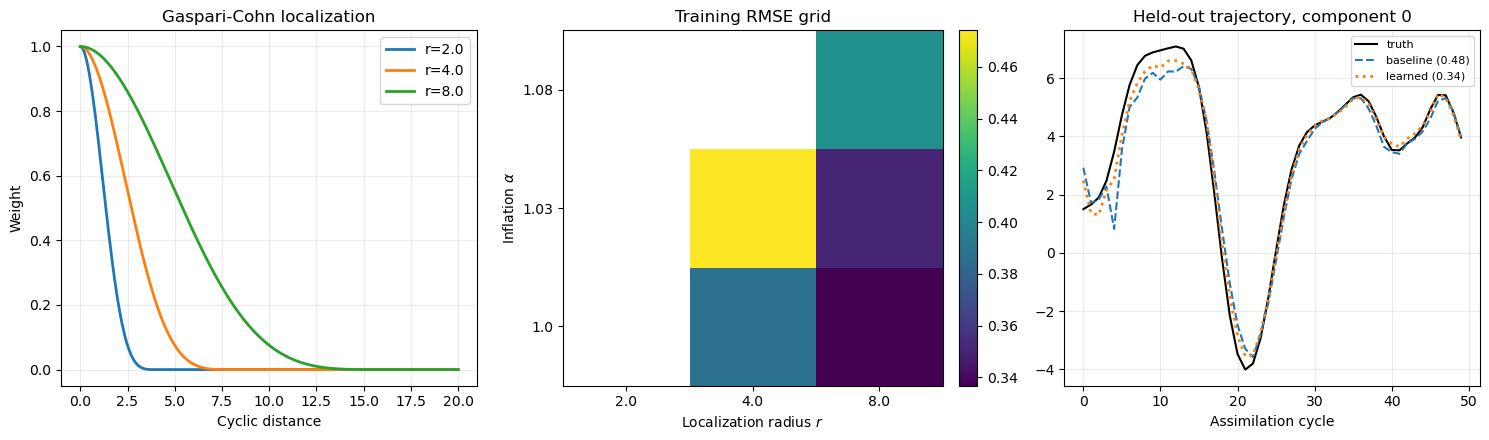

In [1]:
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(all="ignore")

DEFAULTS = {
    "state_dim": 40,
    "forcing": 8.0,
    "dt": 0.01,
    "rk4_steps_per_cycle": 5,
    "cycles": 50,
    "ensemble_size": 30,
    "sigma_v": 0.01,
    "sigma_y": 1.0,
    "baseline_inflation": 1.03,
    "baseline_radius": 4.0,
    "train_trajectories": 4,
    "test_trajectories": 8,
    "alpha_grid": [1.0, 1.03, 1.08],
    "radius_grid": [2.0, 4.0, 8.0],
    "random_seed": 21,
    "force_retrain": False,
}

use_default = False #@param {type:"boolean"}
state_dim = 40 #@param {type:"slider", min:10, max:40, step:2}
cycles = 50 #@param {type:"slider", min:20, max:100, step:10}
ensemble_size = 30 #@param {type:"slider", min:10, max:80, step:5}
sigma_y = 1.0 #@param {type:"slider", min:0.5, max:2.0, step:0.25}
baseline_radius = 4.0 #@param {type:"slider", min:1.0, max:10.0, step:0.5}
force_retrain = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "state_dim": int(state_dim),
        "cycles": int(cycles),
        "ensemble_size": int(ensemble_size),
        "sigma_y": float(sigma_y),
        "baseline_radius": float(baseline_radius),
        "force_retrain": bool(force_retrain),
    })


def checkpoint_path(method_name, params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()[:12]
    path = Path("checkpoints") / "lorenz96_localized_enkf_regularization" / method_name
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{key}.pkl"


def save_checkpoint(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)


def load_checkpoint(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def l96_rhs(v, forcing):
    return (np.roll(v, -1) - np.roll(v, 2)) * np.roll(v, 1) - v + forcing


def rk4_window(v, params):
    x = v.copy()
    dt = params["dt"]
    for _ in range(params["rk4_steps_per_cycle"]):
        k1 = l96_rhs(x, params["forcing"])
        k2 = l96_rhs(x + 0.5 * dt * k1, params["forcing"])
        k3 = l96_rhs(x + 0.5 * dt * k2, params["forcing"])
        k4 = l96_rhs(x + dt * k3, params["forcing"])
        x = x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    return x


def gaspari_cohn(d, radius):
    x = np.abs(d) / max(radius, 1e-8)
    out = np.zeros_like(x, dtype=float)
    m1 = x < 1
    out[m1] = 1 - 5 / 3 * x[m1] ** 2 + 5 / 8 * x[m1] ** 3 + 0.5 * x[m1] ** 4 - 0.25 * x[m1] ** 5
    m2 = (x >= 1) & (x < 2)
    out[m2] = 4 - 5 * x[m2] + 5 / 3 * x[m2] ** 2 + 5 / 8 * x[m2] ** 3 - 0.5 * x[m2] ** 4 + 1 / 12 * x[m2] ** 5 - 2 / (3 * x[m2])
    return out


def cyclic_distance_matrix(n):
    idx = np.arange(n)
    d = np.abs(idx[:, None] - idx[None, :])
    return np.minimum(d, n - d)


def make_l96_trajectory(seed, params):
    rng = np.random.default_rng(seed)
    n = params["state_dim"]
    x = params["forcing"] * np.ones(n)
    x[0] += 0.01
    x += 0.05 * rng.normal(size=n)
    for _ in range(250):
        x = rk4_window(x, params)
    truth = np.empty((params["cycles"], n))
    obs = np.empty_like(truth)
    for t in range(params["cycles"]):
        x = rk4_window(x, params) + params["sigma_v"] * rng.normal(size=n)
        truth[t] = x
        obs[t] = x + params["sigma_y"] * rng.normal(size=n)
    return truth, obs


def run_enkf(truth, obs, alpha, radius, params, seed):
    rng = np.random.default_rng(seed)
    n = params["state_dim"]
    N = params["ensemble_size"]
    ens = truth[0] + rng.normal(scale=1.0, size=(N, n))
    L = gaspari_cohn(cyclic_distance_matrix(n), radius)
    means = []
    nan_flag = False
    for t in range(params["cycles"]):
        ens = np.array([rk4_window(e, params) for e in ens])
        ens += params["sigma_v"] * rng.normal(size=ens.shape)
        mean = ens.mean(axis=0)
        A = ens - mean
        Y = A.copy()
        Cxy = A.T @ Y / (N - 1)
        Cyy = Y.T @ Y / (N - 1) + params["sigma_y"] ** 2 * np.eye(n)
        try:
            K = (L * Cxy) @ np.linalg.solve(Cyy, np.eye(n))
        except np.linalg.LinAlgError:
            nan_flag = True
            break
        innovation = obs[t][None, :] + params["sigma_y"] * rng.normal(size=(N, n)) - ens
        ens = ens + innovation @ K.T
        m = ens.mean(axis=0)
        ens = m + alpha * (ens - m)
        means.append(m)
        if not np.all(np.isfinite(ens)) or np.max(np.abs(ens)) > 1e6:
            nan_flag = True
            break
    if nan_flag or len(means) < params["cycles"]:
        return np.full((params["cycles"], n), np.nan), np.inf
    means = np.array(means)
    rmse = float(np.sqrt(np.mean((means - truth) ** 2)))
    return means, rmse


def evaluate_grid(params):
    train_data = [make_l96_trajectory(params["random_seed"] + i, params) for i in range(params["train_trajectories"])]
    test_data = [make_l96_trajectory(params["random_seed"] + 100 + i, params) for i in range(params["test_trajectories"])]
    grid = np.empty((len(params["alpha_grid"]), len(params["radius_grid"])))
    for ia, alpha in enumerate(params["alpha_grid"]):
        for ir, radius in enumerate(params["radius_grid"]):
            rmses = []
            for k, (truth, obs) in enumerate(train_data):
                _, rmse = run_enkf(truth, obs, alpha, radius, params, params["random_seed"] + 1000 + k)
                rmses.append(rmse)
            grid[ia, ir] = np.mean(rmses)
    best = np.unravel_index(np.nanargmin(grid), grid.shape)
    learned_alpha = params["alpha_grid"][best[0]]
    learned_radius = params["radius_grid"][best[1]]

    def eval_setting(alpha, radius):
        trajs, rmses = [], []
        for k, (truth, obs) in enumerate(test_data):
            means, rmse = run_enkf(truth, obs, alpha, radius, params, params["random_seed"] + 2000 + k)
            trajs.append(means)
            rmses.append(rmse)
        return np.array(trajs), np.array(rmses)

    base_trajs, base_rmse = eval_setting(params["baseline_inflation"], params["baseline_radius"])
    learned_trajs, learned_rmse = eval_setting(learned_alpha, learned_radius)
    return {
        "grid": grid,
        "learned_alpha": learned_alpha,
        "learned_radius": learned_radius,
        "baseline_rmse": base_rmse,
        "learned_rmse": learned_rmse,
        "baseline_trajs": base_trajs,
        "learned_trajs": learned_trajs,
        "test_truth": np.array([x[0] for x in test_data]),
    }


ckpt = checkpoint_path("grid_learning", params)
if ckpt.exists() and not params["force_retrain"]:
    payload = load_checkpoint(ckpt)
    print(f"Loaded checkpoint: {ckpt}")
else:
    payload = evaluate_grid(params)
    save_checkpoint(ckpt, payload)
    print(f"Saved checkpoint: {ckpt}")

print(f"Learned regularization: alpha={payload['learned_alpha']}, radius={payload['learned_radius']}")
print(f"Baseline RMSE: {np.nanmean(payload['baseline_rmse']):.3f}")
print(f"Learned RMSE:  {np.nanmean(payload['learned_rmse']):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

d = np.linspace(0, params["state_dim"] / 2, 300)
for r in params["radius_grid"]:
    axes[0].plot(d, gaspari_cohn(d, r), lw=2, label=f"r={r}")
axes[0].set_title("Gaspari-Cohn localization")
axes[0].set_xlabel("Cyclic distance")
axes[0].set_ylabel("Weight")
axes[0].legend()
axes[0].grid(alpha=0.25)

im = axes[1].imshow(payload["grid"], origin="lower", aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(params["radius_grid"])), params["radius_grid"])
axes[1].set_yticks(range(len(params["alpha_grid"])), params["alpha_grid"])
axes[1].set_xlabel("Localization radius $r$")
axes[1].set_ylabel("Inflation $\\alpha$")
axes[1].set_title("Training RMSE grid")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

truth0 = payload["test_truth"][0]
base0 = payload["baseline_trajs"][0]
learned0 = payload["learned_trajs"][0]
dim = 0
axes[2].plot(truth0[:, dim], "k-", lw=1.5, label="truth")
axes[2].plot(base0[:, dim], "C0--", label=f"baseline ({np.nanmean(payload['baseline_rmse']):.2f})")
axes[2].plot(learned0[:, dim], "C1:", lw=2, label=f"learned ({np.nanmean(payload['learned_rmse']):.2f})")
axes[2].set_title("Held-out trajectory, component 0")
axes[2].set_xlabel("Assimilation cycle")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
